In [2]:
# Standard libraries
import os
import itertools
import math

# EEG & Signal Processing
import mne 
from mne.preprocessing import ICA
from mne_connectivity import spectral_connectivity_epochs, envelope_correlation
from mne.time_frequency import stft, psd_array_welch
from scipy.stats import differential_entropy
from scipy.signal import butter, filtfilt
from asrpy import ASR

# Data manip
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import scipy.io as sio

# Graph
import networkx as nx

# Torch geometric
import torch_geometric
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv, SAGEConv, GINConv
from torch_geometric.utils import dropout_edge
from torch_geometric.nn.norm import BatchNorm
from torch_geometric.nn import global_mean_pool, global_add_pool, global_max_pool
from torch_geometric.explain import Explainer, GNNExplainer

# Torch
import torch
import torch.nn.functional as F
import torch.nn as nn

/Users/jasonlee/Desktop/personal_projects/alzheimers/graph/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Collecting all files with specific ext
def find_files(data_path, ext):
    found_files = []
    for root, _, files in os.walk(data_path):
        for file in files:
            if file.endswith(ext):
                full_path = os.path.join(root, file)
                found_files.append(full_path)
                
    return found_files

# EEGGraphBuilder Class

In [4]:
class EEGGraphBuilder:
    def __init__(
        self,
        file_path,
        clean=False,
        sfreq=None,
        epoch_length=30.0,
        epoch_overlap=15.0,
        fmin=0.5,
        fmax=45,
        edge_threshold=75,
        fc_method='plv',
        node_feature='stft'
    ):
        self.file_path = file_path
        self.epoch_length = epoch_length
        self.epoch_overlap = epoch_overlap
        self.fc_method = fc_method
        self.fmin = fmin
        self.fmax = fmax
        self.edge_threshold = edge_threshold
        self.node_feature = node_feature

        # Placeholders until initialized
        self.raw = None
        self.epochs = None
        self.node_features = None
        self.edge_features = None
        self.edge_index = None


        # Raw file and sampling freq
        raw_load = mne.io.read_raw_eeglab(self.file_path, preload=True)
        
        # Cleaning EEG
        if not clean:
            self.raw = self.clean_eeg(raw_load)
        else:
            self.raw = raw_load
            
        self.sfreq = self.raw.info['sfreq']
        
        
    def clean_eeg(self, raw, l_freq=0.5, h_freq=45, asr_sd=17, n_components=None, 
              method='fastica', random_state=99, extreme_thresh=2.0, 
              percent_threshold=10):

        # Filter and create copy
        raw_for_fit = raw.copy().filter(l_freq=l_freq, h_freq=h_freq, method='fir', verbose=False)

        # Artifact Subspace Retrieval 
        asr_obj = ASR(sfreq=raw.info['sfreq'], cutoff=asr_sd) 
        asr_obj.fit(raw_for_fit)
        raw_for_fit = asr_obj.transform(raw_for_fit)
            
        # ICA fitting
        ica = ICA(n_components=n_components, method=method, random_state=random_state)
        ica.fit(raw_for_fit, verbose=False)

        # Extreme signal activity
        sources = ica.get_sources(raw_for_fit).get_data()  # shape: n_components x n_times
        z_sources = np.abs((sources - sources.mean(axis=1, keepdims=True)) / sources.std(axis=1, keepdims=True))

        # Calculate exceeds threshold
        percent_extreme = np.mean(z_sources > extreme_thresh, axis=1) * 100

        # Identify components where the "extreme" percentage is too high
        reject_components = [i for i, perc in enumerate(percent_extreme) if perc >= percent_threshold]
        ica.exclude = reject_components

        # Create final clean object
        raw_clean = ica.apply(raw_for_fit.copy())

        return raw_clean
        
        
    def create_epoch(self):
        # shape (n_epochs, n_chan, n_times)
        self.epochs = mne.make_fixed_length_epochs(self.raw, duration=self.epoch_length, overlap=self.epoch_overlap, preload=True) 
        self.n_epochs = len(self.epochs) # store n epochs as attribute to method
        
        return self.epochs
    
    def compute_node_features(self, epoch_idx):
        if self.node_feature == 'stft':
            return self._compute_node_features_stft(epoch_idx)
        
        elif self.node_feature == 'hjorth':
            return self._compute_node_features_hjorth(epoch_idx)
        
        elif self.node_feature == 'psd':
            return self._compute_node_features_psd(epoch_idx)
        
        elif self.node_feature == 'de':
            return self._compute_node_features_de(epoch_idx)
        
        else:
            print("Pick either: stft, hjorth, psd, or de")
        
    def _compute_node_features_stft(self, epoch_idx):
        data = self.epochs.get_data()[epoch_idx] 
        wsize = 256
        tstep = 128
    
        # Compute stft and take the abs (magnitude)
        stft_data = stft(data, wsize=wsize, tstep=tstep)
        stft_mag = np.abs(stft_data) # shape (n_chan, n_filter_freq, n_time_steps)

        # Frequency mask
        freqs = np.fft.rfftfreq(wsize, d=1.0/self.sfreq)
        freq_mask = (freqs >= self.fmin) & (freqs <= self.fmax) # Adjust min/max to focus on certain freq bands
        
        # Average over time
        node_features = stft_mag[:, freq_mask, :].mean(axis=2)
        
        return node_features # (n_chan, n_freq_bins)
    
    def _compute_node_features_hjorth(self, epoch_idx):
        data = self.epochs.get_data()[epoch_idx]
        
        # 3 Hjorth parameters
        activity = np.var(data, axis=1)
        mobility = np.sqrt(
            np.var(np.diff(data, axis=1), axis=1) / activity
        )
        complexity = (
            np.sqrt(
                np.var(np.diff(np.diff(data, axis=1), axis=1), axis=1)
                / np.var(np.diff(data, axis=1), axis=1)
            ) / mobility
        )

        return np.stack([activity, mobility, complexity], axis=1)
        
    def _compute_node_features_psd(self, epoch_idx):
        data = self.epochs.get_data()[epoch_idx]        
        psd, freq = psd_array_welch(data, self.sfreq, self.fmin, self.fmax) # Adjust min/max to focus on certain freq bands
        
        return psd # (n_chan, nfreq)
        
    def _bandpass(self, data, low, high, order=4):
        nyq = 0.5 * self.sfreq
        b, a = butter(order, [low/nyq, high/nyq], btype='band')
        return filtfilt(b, a, data)

    def _compute_node_features_de(self, epoch_idx):
        data = self.epochs.get_data()[epoch_idx]

        # Canonical freq band range
        bands = {
            "delta": (0.5, 4),
            "theta": (4, 8),
            "alpha": (8, 13),
            "beta":  (13, 30),
            "gamma": (30, 45)
        }

        de_features = []

        for low, high in bands.values():
            band_de = []
            for chan in data:
                band_signal = self._bandpass(chan, low, high)
                var = np.var(band_signal)
                de = 0.5 * np.log(2 * np.pi * np.e * var + 1e-8)
                band_de.append(de)
            de_features.append(band_de)

        return np.array(de_features).T # (n_chan, n_bands)
    
    def compute_edge_features(self, epoch_idx):
        # FC measures using spectral_connectivity_epochs method
        mne_fc_methods = ['plv', 'coh', 'pli', 'wpli', 'gc', 'imcoh']

        if self.fc_method.lower() in mne_fc_methods:
            # Slice 1 epoch
            epoch_slice = self.epochs[epoch_idx:epoch_idx + 1]

            conn = spectral_connectivity_epochs(
                epoch_slice,
                method=self.fc_method,
                fmin=self.fmin,
                fmax=self.fmax,
                faverage=True,
                verbose=False
            )

            # Dense FC matrix (n_channels, n_channels)
            fc_matrix = conn.get_data(output="dense")[:, :, 0]

            return self._compute_edge_features_threshold(fc_matrix)
        
        elif self.fc_method == 'aec':
            return self._compute_edge_features_aec(epoch_idx)
        
        elif self.fc_method == 'corr':
            return self._compute_edge_features_corr(epoch_idx)
    
    def compute_edge_brain_region(self, adj_list):
        # Inputs a list of tuple (i,j) relationship
        # Ex. [ (Fp1, Fp2), (O1,O2) ]
        n_chan = len(self.raw.ch_names)
        fc_matrix = np.zeros((n_chan,n_chan))
        
        # Create a mapping dictionary for quick lookup
        ch_map = {name: i for i, name in enumerate(self.raw.ch_names)}
        
        for ch_a, ch_b in adj_list:
            if ch_a in ch_map and ch_b in ch_map:
                i, j = ch_map[ch_a], ch_map[ch_b]
                fc_matrix[i, j] = 1.0
                fc_matrix[j, i] = 1.0
            else:
                print(f"Warning: Channels {ch_a} or {ch_b} not found in data.")
     
        # PyG input
        mask = fc_matrix > 0 
        edge_index = np.array(np.where(mask))
        edge_attr = fc_matrix[mask][:, None]  
        
        return fc_matrix, edge_index, edge_attr
    
    def _compute_edge_features_threshold(self, fc_matrix):
        # Remove self loops
        np.fill_diagonal(fc_matrix, 0)

        # Thresholding
        thresh = np.percentile(fc_matrix, self.edge_threshold)
        mask = fc_matrix >= thresh

        # PyG inputs
        edge_index = np.array(np.where(mask))           
        edge_attr = fc_matrix[mask][:, None]        

        return fc_matrix, edge_index, edge_attr

    def _compute_edge_features_aec(self, epoch_idx):
        epoch_slice = self.epochs[epoch_idx:epoch_idx + 1]

        # Compute envelope corr
        corr_obj = envelope_correlation(epoch_slice, orthogonalize=True, absolute=True)
        fc_matrix = corr_obj.combine().get_data(output='dense')[:, :, 0] # (n_chan, n_chan)
        
        return self._compute_edge_features_threshold(fc_matrix)
        
    def _compute_edge_features_corr(self, epoch_idx):
        data = self.epochs.get_data()[epoch_idx]
        fc_matrix = np.corrcoef(data)  # shape: (n_channels, n_channels)

        return self._compute_edge_features_threshold(fc_matrix)

# PyG Data class

In [5]:
class EEGGraphPyG(EEGGraphBuilder):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        
    def pyg_data(self, epoch_idx):
        node_features = self.compute_node_features(epoch_idx)  # np array (n_nodes, n_node_features)
        x = torch.tensor(node_features, dtype=torch.float)

        # Edge features
        fc_matrix, edge_index, edge_attr = self.compute_edge_features(epoch_idx)
        edge_index = torch.tensor(edge_index, dtype=torch.long)
        edge_attr = torch.tensor(edge_attr, dtype=torch.float)

        # Naming PyG nodes
        chan_names = self.raw.ch_names
        
        # Return PyG data object
        data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr)        
        data.node_names = chan_names
        
        return data

# Visualize Graphs

In [6]:
class EEGGraphPlot():
    def __init__(self, eeg_builder_obj):
        self.builder = eeg_builder_obj
        
    def plot(self, adj_matrix, title='Graph'):
        node_labels = self.builder.raw.ch_names
        
        # Montage info
        montage = self.builder.raw.get_montage()
        pos_3d = montage.get_positions()['ch_pos']
        pos = {ch: pos_3d[ch][:2] for ch in node_labels} # from 3d to 2d format
        
        # Build Networkx Graph
        G = nx.from_numpy_array(adj_matrix)
        label_mapping = {i: ch for i, ch in enumerate(node_labels)} # Labeling nodes
        G = nx.relabel_nodes(G, label_mapping) 
        
        # Plot Shape
        plt.figure(figsize=(10, 8))
        plt.title(title)
        
        # Draw nodes based on montage position
        nx.draw_networkx_nodes(G, pos, node_size=500, node_color='lightblue')
        nx.draw_networkx_labels(G, pos, font_size=8)
        
        # Draw variable edge width based on fc weight
        edges, weights = zip(*nx.get_edge_attributes(G,'weight').items()) 
        nx.draw_networkx_edges(G, pos, edgelist=edges, width=np.array(weights)*5)

        plt.show()

## Visualize brain region graph

Applying ICA to Raw instance
    Transforming to ICA space (16 components)
    Zeroing out 0 ICA components
    Projecting back using 19 PCA components
Not setting metadata
38 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 38 events and 15000 original time points ...
0 bad epochs dropped


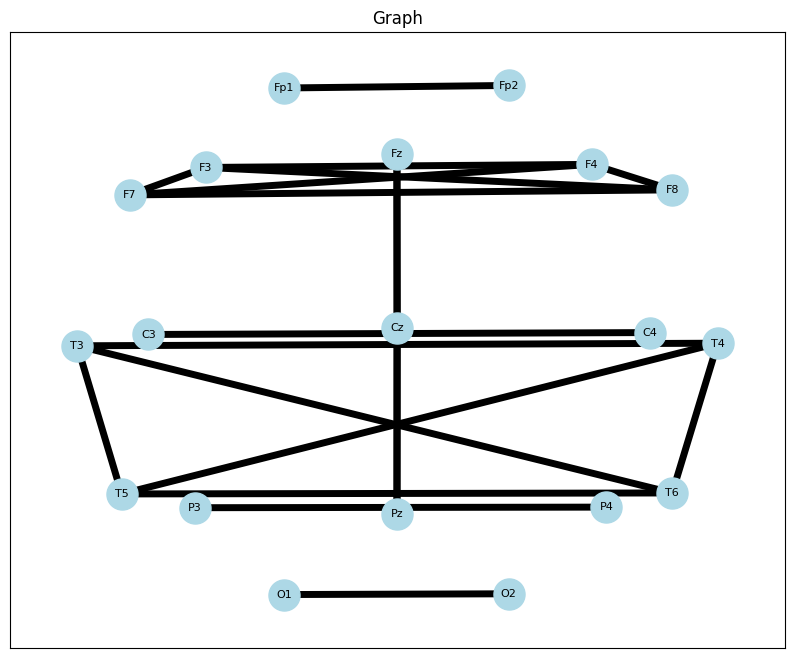

In [7]:
# Load data
file_path = '/Users/jasonlee/Desktop/personal_projects/alzheimers/graph/dataset/openneuro - AD/regular/sub-001_task-eyesclosed_eeg (2).set'
eeg_obj = EEGGraphBuilder(file_path)
eeg_obj.create_epoch()

# Generate matrix
adj_list = [
            ('Fp1', 'Fp2'), 
            ('O1', 'O2'),   
            ('Fz', 'Cz'), ('Fz', 'Pz'), ('Cz', 'Pz'),
            ('F7', 'F3'), ('F7', 'F4'), ('F7', 'F8'), ('F3', 'F4'), ('F3', 'F8'), ('F4', 'F8'),
            ('C3', 'C4'), 
            ('T3', 'T5'), ('T3', 'T4'), ('T3', 'T6'), ('T4', 'T6'), ('T5', 'T6'), ('T4', 'T5'),
            ('P3', 'P4')
            ]
fc_matrix, _, _ = eeg_obj.compute_edge_brain_region(adj_list)

# Pass the eeg_obj to the plotter
plotter = EEGGraphPlot(eeg_obj)
plotter.plot(fc_matrix)

# Patients EEG -> EEGGraphBuilder -> Dataloader

In [8]:
# Create list of PyG data objects 
def eeg_graph_list(eeg_files, patient_tsv, ad_pd='ad',
                epoch_length=30.0, epoch_overlap=15.0, 
                fc_method='plv', node_feature='de', edge_threshold=90, 
                fmin=0.5, fmax=45,
                save=None
                ):
    assert save, "If parameter is True then include file path as the parameter"
    assert ad_pd, "Parameter must be either ad or pd"
    
    # Loading tsv file
    df = pd.read_csv(patient_tsv, sep='\t')
    

    # Loop through all patients
    epoch_graphs = []
    for file in eeg_files:
        # Get sub ID
        file_name = os.path.basename(file)
        sub_id = file_name.split('_')[0]
        
        # Safety check
        row = df.loc[df['participant_id'] == sub_id]
        if row.empty:
            print(f"No score found for {sub_id}")
            continue
        
        # Data.y MMSE or MOCA
        if ad_pd == 'ad':
            data_y = row['MMSE'].iloc[0]      # MMSE 
            sub_label = row['Group'].iloc[0]  # Diagnosis label
        elif ad_pd == 'pd':
            data_y = row['MOCA'].iloc[0]      # MOCA
            sub_label = row['GROUP'].iloc[0]  

        # Cleaning pd dataset
        if ad_pd == 'pd':
            clean=True
        else: 
            clean=False
            
        # Create EEG Object
        eeg_obj = EEGGraphPyG(
                file_path=file,
                clean=clean,
                epoch_length=epoch_length,
                epoch_overlap=epoch_overlap,
                fc_method=fc_method,
                node_feature=node_feature,
                edge_threshold=edge_threshold
            )
        eeg_obj.create_epoch()

        # Turn each epoch into PyG data obj
        for epoch_idx in range(eeg_obj.n_epochs):
            data = eeg_obj.pyg_data(epoch_idx)
            data.y = torch.tensor([data_y], dtype=torch.float32)   # Adding MMSE as data.y label
            data.subject_id = sub_id                               # Adding subject_id attribute
            data.label = sub_label                                 # Adding diagnosis label
            
            epoch_graphs.append(data)
            
    # Saving list of objects for next time
    if save:
        torch.save(epoch_graphs, save)
        print(f"Saved {len(epoch_graphs)} graphs to {save}")
    
    return epoch_graphs


# Takes a list of PyG data objects and splits data to create 3 dataloaders
def subject_loader(graph_list, sub_split='norm', batch_size=16):
    # Getting list of all unique subjects
    subjects = list(set(d.subject_id for d in graph_list))

    # How to Split Subjects
    if sub_split == 'norm':
        # ==== 70 / 15 / 15 Random split =====
        train_subs, extra_subs = train_test_split(subjects, test_size=0.3, random_state=42)
        val_subs, test_subs = train_test_split(extra_subs, test_size=0.5, random_state=42)

        # List of epoch graphs for subjects
        train_data = [d for d in graph_list if d.subject_id in train_subs]
        test_data  = [d for d in graph_list if d.subject_id in test_subs]
        val_data  = [d for d in graph_list if d.subject_id in val_subs]
        
    elif sub_split == 'strat':
        # ==== Stratified subject wise splitting =====
        
        # Map every subject to their specific label
        sub_to_label = {d.subject_id: d.label for d in graph_list}
        
        # Dict: {'A': [sub1, sub2], 'C': [sub5, sub6], ...}
        label_to_subs = {}
        for sub_id, label in sub_to_label.items():
            if label not in label_to_subs: # Creates key if not exists
                label_to_subs[label] = []
            label_to_subs[label].append(sub_id)

        all_train_subs, all_val_subs, all_test_subs = [], [], []

        # Loop through each label group and split them individually
        for label, sub_list in label_to_subs.items():            
            # 70/15/15 split per label
            train_subs, extra_subs = train_test_split(sub_list, test_size=0.3, random_state=42)
            val_subs, test_subs = train_test_split(extra_subs, test_size=0.5, random_state=42)

            all_train_subs.extend(train_subs)
            all_val_subs.extend(val_subs)
            all_test_subs.extend(test_subs)

        train_data = [d for d in graph_list if d.subject_id in all_train_subs]
        val_data   = [d for d in graph_list if d.subject_id in all_val_subs]
        test_data  = [d for d in graph_list if d.subject_id in all_test_subs]
    
    train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)
    test_loader  = DataLoader(test_data, batch_size=batch_size, shuffle=False)
    
    return train_loader, val_loader, test_loader

## Testing Datasets

### Alzheimers

In [9]:
# ===== Testing functions =====
processed_path = 'epoch_graphs_samp.pt'

if os.path.exists(processed_path):
    print("Loading processed graphs")
    epoch_graphs = torch.load(processed_path)
    print(f"Loaded {len(epoch_graphs)} graphs.")
    
    train_loader, val_loader, test_loader = subject_loader(epoch_graphs, sub_split='strat', batch_size=16)
    print(f"Dataloader for graphs ready")
    
else:
    # Find files
    file_path = '/Users/jasonlee/Desktop/personal_projects/alzheimers/graph/dataset/openneuro - AD/regular'
    patient_tsv = '/Users/jasonlee/Desktop/personal_projects/alzheimers/graph/dataset/openneuro - AD/participants.tsv'
    df = pd.read_csv(patient_tsv, sep='\t')
    all_files = find_files(file_path, '.set')

    epoch_graphs = eeg_graph_list(
        all_files, 
        patient_tsv, 
        ad_pd='ad', 
        epoch_length=10.0, epoch_overlap=5.0,
        fc_method='plv', node_feature='psd', edge_threshold=90, 
        fmin=0.5, fmax=45.0,
        save=processed_path
        )


# ===== Testing correct prints =====
train_loader, val_loader, test_loader = subject_loader(epoch_graphs, 'strat') # load batches
first_batch = next(iter(train_loader)) # Returns a list with len == batch_size

print(first_batch[0]) # First graph
print(f"\nGraph sample data \nSubject ID: {first_batch.subject_id[0]} \nMMSE Score: {first_batch.y[0]} \nLabel: {first_batch.label[0]}")

Loading processed graphs
Loaded 4400 graphs.
Dataloader for graphs ready
Data(x=[19, 5], edge_index=[2, 171], edge_attr=[171, 1], node_names=[19], y=[1], subject_id='sub-024', label='A')

Graph sample data 
Subject ID: sub-024 
MMSE Score: 20.0 
Label: A


### Parkinsons 

In [10]:
# # ===== Testing functions =====
# processed_path = 'pd_epoch_samp.pt'

# if os.path.exists(processed_path):
#     print("Loading processed graphs from local storage...")
#     epoch_graphs = torch.load(processed_path)
#     print(f"Loaded {len(epoch_graphs)} graphs.")
# else:
#     # Find files
#     file_path = '/Users/jasonlee/Desktop/personal_projects/alzheimers/graph/dataset/pd'
#     patient_tsv = '/Users/jasonlee/Desktop/personal_projects/alzheimers/graph/dataset/pd/participants.tsv'
#     df = pd.read_csv(patient_tsv, sep='\t')

#     all_files = find_files(file_path, '.set')
#     # all_files = all_files[0:2]

#     epoch_graphs = eeg_graph_list(all_files, patient_tsv, ad_pd='pd', save=processed_path) # Cleans eeg w/ ad_pd='pd'


# # ===== Testing correct prints =====
# train_loader, val_loader, test_loader = subject_loader(epoch_graphs, 'strat') # load batches
# first_batch = next(iter(train_loader)) # Returns a list with len == batch_size

# print(first_batch[0]) 
# print(f"\nGraph sample data \nSubject ID: {first_batch.subject_id[0]} \nMOCA Score: {first_batch.y[0]} \nLabel: {first_batch.label[0]}")

## GCN

In [11]:
class GCN(nn.Module):
    def __init__(self, hidden_size, out_chan, edge_drop=0.1, feat_drop=0.2):
        super(GCN, self).__init__()
        self.edge_drop = edge_drop
        self.feat_drop = feat_drop
        
        # 1st layer        
        self.conv1 = GCNConv(-1, hidden_size) # Lazy infer in chan for 1st gcn conv layer
        self.bn1 = BatchNorm(hidden_size)

        # 2nd layer
        self.conv2 = GCNConv(hidden_size, out_chan)
        self.bn2 = BatchNorm(out_chan)   
        
        # MLP
        self.mlp = nn.Sequential(
            nn.Linear(out_chan * 3, 128),
            nn.ReLU(),
            nn.Dropout(feat_drop),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        ) # 1 scalar output for MMSE or MOCA score
        
    def forward(self, x, edge_index, batch):
        # Edge dropout (training only)
        if self.training:
            edge_index, _ = dropout_edge(edge_index, p=self.edge_drop)

        # 1st layer      
        x = self.conv1(x, edge_index)
        x = self.bn1(x)
        x = F.relu(x)
        x = F.dropout(x, p=self.feat_drop, training=self.training)

        # 2nd layer
        x = self.conv2(x, edge_index)
        x = self.bn2(x)
        x = F.relu(x)
        # x = F.dropout(x, p=self.feat_drop, training=self.training)
        
        # Graph readout 
        avg_x = global_mean_pool(x, batch)
        sum_x = global_add_pool(x, batch)
        max_x = global_max_pool(x, batch)
        
        concat_x = torch.cat((avg_x, sum_x, max_x), dim=1)
        
        # MLP
        out = self.mlp(concat_x)
        # out = 30 * torch.sigmoid(out)

        return out

# Training

In [12]:
def train(train_loader, val_loader, y_mean, y_std):
    # Training
    model.train()
    total_loss = 0
    
    for data in train_loader:
        data = data.to(device)
        optimizer.zero_grad()
        
        out = model(data.x, data.edge_index, data.batch).view(-1)
        
        # Normalizing target
        y_norm = (data.y.view(-1) - y_mean) / y_std
        loss = criterion(out, y_norm)
        
        # Backpropagation
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item() * data.num_graphs
        
    avg_train_loss = total_loss / len(train_loader.dataset)
        
    # Validation
    model.eval()
    val_loss = 0
    
    with torch.no_grad():
        for val_data in val_loader:
            val_data = val_data.to(device)
            
            out = model(val_data.x, val_data.edge_index, val_data.batch).view(-1)
            
            # Normalize
            y_norm = (val_data.y.view(-1) - y_mean) / y_std
            loss = criterion(out, y_norm)

            val_loss += loss.item() * val_data.num_graphs
        
        avg_val_loss = val_loss / len(val_loader.dataset)
    
    return avg_train_loss, avg_val_loss
    
    
def evaluate(loader):
    model.eval()
    
    # Regression metrics
    total_mae = 0
    total_sse = 0
    total_mape = 0
    
    # Print pred & actual
    all_pred = []
    all_actual = []
    
    eps = 1e-8
    with torch.no_grad():
        for data in loader:
            data = data.to(device)
            
            pred_norm = model(data.x, data.edge_index, data.batch).view(-1)

            # Denormalize
            pred = pred_norm * y_std + y_mean
            errors = pred - data.y.view(-1)
            
            total_mae += torch.abs(errors).sum().item()
            total_sse += torch.square(errors).sum().item()        
            
            actual = data.y.view(-1)
            errors = pred - actual
            
            all_pred.extend(pred)
            all_actual.extend(actual)
            
            abs_errors = torch.abs(errors)
            mape_batch = (abs_errors / (torch.abs(actual) + eps)).sum().item()
            total_mape += mape_batch
        
        all_pred = np.array(all_pred)
        all_actual = np.array(all_actual)
            
        n = len(loader.dataset)
        mae = total_mae / n
        
        eps = 1e-8
        mape = (total_mape / n) * 100
        
        mse = total_sse / n
        rmse = math.sqrt(mse)
        
    return mae, mape, rmse, all_pred, all_actual


# Hyperparameters
hidden_size = 128
out_chan = 64
lr = 1e-4
feat_drop = 0.2
edge_drop = 0.1

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = GCN(hidden_size, out_chan, edge_drop, feat_drop).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
criterion = torch.nn.MSELoss()
# criterion = torch.nn.SmoothL1Loss(beta=1.0) 

# Validation
best_val_loss = float('inf')
best_model_state = None
epochs_no_improve = 0
n_epochs = 25
patience = 5

# Loss lists
train_loss = []
val_loss = []


# Compute target normalization stats on train_loader
all_train_y = []

for data in train_loader.dataset:
    all_train_y.append(data.y.view(-1))

all_train_y = torch.cat(all_train_y)

y_mean = all_train_y.mean().to(device)
y_std = all_train_y.std().to(device)

print("Target mean:", y_mean.item())
print("Target std:", y_std.item())


# Training loop
for epoch in range(n_epochs):
    current_train_loss, current_val_loss = train(train_loader, val_loader, y_mean, y_std)
    train_loss.append(current_train_loss)
    val_loss.append(current_val_loss)
    
    if current_val_loss < best_val_loss:
        best_val_loss = current_val_loss
        best_model_state = model.state_dict()
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        
    print(f"Epoch {epoch+1} | Train Loss: {current_train_loss:.4f} | Val Loss: {current_val_loss:.4f}")
    
    if epochs_no_improve >= patience:
        print(f"Early stopping triggered after {epoch+1} epochs.")
        break

Target mean: 22.60999298095703
Target std: 6.53151273727417
Epoch 1 | Train Loss: 1.0506 | Val Loss: 0.7099
Epoch 2 | Train Loss: 0.9410 | Val Loss: 0.6943
Epoch 3 | Train Loss: 0.9075 | Val Loss: 0.8002
Epoch 4 | Train Loss: 0.8981 | Val Loss: 1.3201
Epoch 5 | Train Loss: 0.8983 | Val Loss: 0.9352
Epoch 6 | Train Loss: 0.8718 | Val Loss: 0.6623
Epoch 7 | Train Loss: 0.8529 | Val Loss: 0.8609
Epoch 8 | Train Loss: 0.8728 | Val Loss: 0.6296
Epoch 9 | Train Loss: 0.8628 | Val Loss: 0.9453
Epoch 10 | Train Loss: 0.8490 | Val Loss: 0.7204
Epoch 11 | Train Loss: 0.8460 | Val Loss: 0.5782
Epoch 12 | Train Loss: 0.8436 | Val Loss: 0.6216
Epoch 13 | Train Loss: 0.8252 | Val Loss: 1.1046
Epoch 14 | Train Loss: 0.8385 | Val Loss: 0.6520
Epoch 15 | Train Loss: 0.8203 | Val Loss: 0.5333
Epoch 16 | Train Loss: 0.8207 | Val Loss: 0.5801
Epoch 17 | Train Loss: 0.8302 | Val Loss: 0.8468
Epoch 18 | Train Loss: 0.8298 | Val Loss: 1.2496
Epoch 19 | Train Loss: 0.8206 | Val Loss: 0.5597
Epoch 20 | Train L

# Evaluate

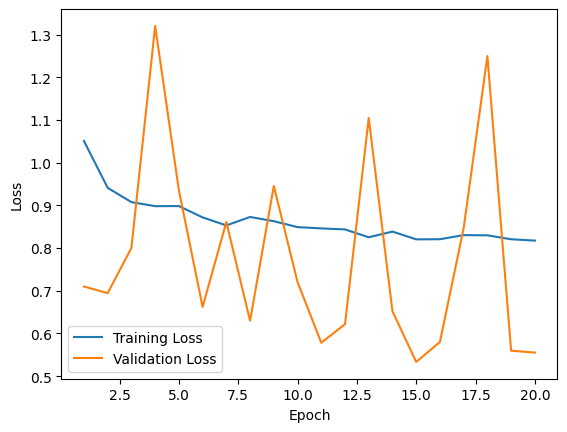

MAE: 4.5278 | MAPE: 20.1531 | RMSE: 5.1255
Index    | Prediction   | Pred Round   | Actual       | Diff        
--------------------------------------------------
0        | 26.8393      | 27.0000      | 20.0000      | 6.8393      
1        | 27.2860      | 27.0000      | 20.0000      | 7.2860      
2        | 27.0911      | 27.0000      | 20.0000      | 7.0911      
3        | 26.4564      | 26.0000      | 20.0000      | 6.4564      
4        | 26.7500      | 27.0000      | 20.0000      | 6.7500      
5        | 26.0427      | 26.0000      | 20.0000      | 6.0427      
6        | 25.5351      | 26.0000      | 20.0000      | 5.5351      
7        | 25.9588      | 26.0000      | 20.0000      | 5.9588      
8        | 26.5157      | 27.0000      | 20.0000      | 6.5157      
9        | 25.9360      | 26.0000      | 20.0000      | 5.9360      
10       | 25.9068      | 26.0000      | 20.0000      | 5.9068      
11       | 26.8631      | 27.0000      | 20.0000      | 6.8631      
12       

In [13]:
# Plot loss
x = list(range(1, len(train_loss)+1))
plt.plot(x, train_loss, label = 'Training Loss')
plt.plot(x, val_loss, label = 'Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


# Printing evaluation
mae, mape, rmse, preds, actuals = evaluate(test_loader)
preds_round = np.round(preds)

print(f'MAE: {mae:.4f} | MAPE: {mape:.4f} | RMSE: {rmse:.4f}')

print(f"{'Index':<8} | {'Prediction':<12} | {'Pred Round':<12} | {'Actual':<12} | {'Diff':<12}")
print("-" * 50)
for i, (p, pr, a) in enumerate(zip(preds, preds_round, actuals)):
    diff = p - a
    print(f"{i:<8} | {p:<12.4f} | {pr:<12.4f} | {a:<12.4f} | {diff:<12.4f}")

print("-" * 50)


# Printing unique values
unique_values, counts = np.unique(preds_round, return_counts=True)
col_width = 6 

# Format rows
val_row = "".join(f"{str(int(v)):>{col_width}}" for v in unique_values)
cnt_row = "".join(f"{str(c):>{col_width}}" for c in counts)

print("Unique Values:", val_row)
print("Counts:       ", cnt_row)
print("-" * 50)


# Average diff per MMSE score
mmse_dict = {}
for pred, actual in zip(preds, actuals):
    diff = np.abs(pred - actual)
    
    if actual not in mmse_dict.keys():
        mmse_dict[actual] = []
    mmse_dict[actual].append(diff)

print(f"{'MMSE Score':<12} | {'Avg Abs Diff':<15} | {'Samples':<8}")
print("-" * 50)

for mmse in sorted(mmse_dict.keys()):
    diffs = mmse_dict[mmse]
    avg_diff = np.mean(diffs)
    count = len(diffs)
    
    print(f"{mmse:<12.1f} | {avg_diff:<15.4f} | {count:<8}")

# Explainable Function


Top Nodes:
1. Cz (idx=17)
2. Pz (idx=18)
3. Fz (idx=16)
4. T6 (idx=15)
5. T5 (idx=14)
6. T4 (idx=13)
7. T3 (idx=12)
8. F8 (idx=11)
9. F7 (idx=10)
10. O2 (idx=9)

Top Edges:
1. ('Cz', 'Fz') (idx=152)
2. ('Pz', 'Cz') (idx=170)
3. ('Pz', 'F7') (idx=163)
4. ('Pz', 'T5') (idx=167)
5. ('O1', 'P3') (idx=34)
6. ('Cz', 'T6') (idx=151)
7. ('Fz', 'T6') (idx=135)
8. ('Pz', 'T6') (idx=168)
9. ('Pz', 'T3') (idx=165)
10. ('Fz', 'O2') (idx=129)


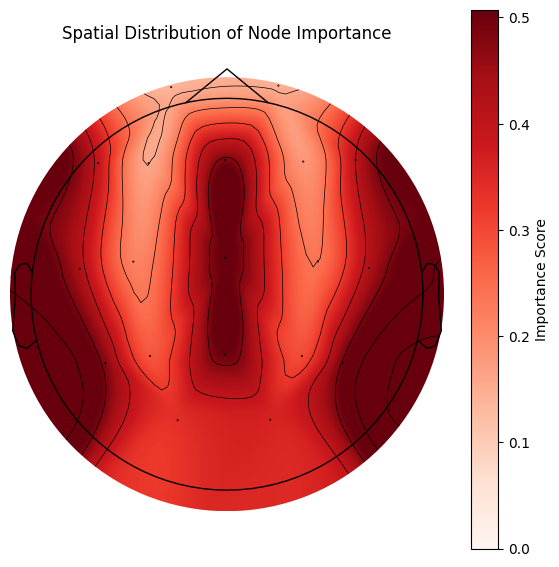

In [14]:
def node_explain(model, graph, explanation_type, node_aggr = 'mean', plot=False, print_results=False):
    data = graph.to(device)
    node_names = data.node_names
    batch = torch.zeros(data.x.size(0), dtype=torch.long).to(device)
    
    if explanation_type == 'model':
        explainer = Explainer(
        model=model,
        algorithm=GNNExplainer(epochs=200),
        explanation_type='model',       
        node_mask_type='attributes',
        edge_mask_type='object',
        model_config=dict(
            mode='regression',          
            task_level='graph',      
            return_type='raw'
            )
        )
        explanation = explainer(
            x=data.x,
            edge_index=data.edge_index,
            batch=batch
        )
    else:
        explainer = Explainer(
        model=model,
        algorithm=GNNExplainer(epochs=200),
        explanation_type='phenomenon',      
        node_mask_type='attributes',
        edge_mask_type='object',
        model_config=dict(
            mode='regression',          
            task_level='graph',      
            return_type='raw'
            )
        )

        # De-Normalize
        pred_norm = model(data.x, data.edge_index, batch)
        pred = pred_norm * y_std + y_mean
        y_norm = (data.y - y_mean) / y_std

        # Generate explanation
        explanation = explainer(
            x=data.x,
            edge_index=data.edge_index,
            batch=batch,
            target=y_norm.view(-1)
        )
    
    # Ranking node importance
    if node_aggr == 'mean':
        node_importance = explanation.node_mask.mean(dim=1)
    elif node_aggr == 'sum':
        node_importance = explanation.node_mask.sum(dim=1)
        
    top_nodes_idx = torch.argsort(node_importance, descending=True)
    
    top_nodes = []
    for idx in top_nodes_idx:
        top_nodes.append(node_names[idx.item()])
    
    
    # Ranking edge importance
    edge_importance = explanation.edge_mask
    top_edges_idx = torch.argsort(edge_importance, descending=True)
    
    top_edges = [] # list of tuples
    for idx in top_edges_idx:
        n1 = data.edge_index[0, idx].item()
        n2 = data.edge_index[1, idx].item()
        edge_tuple = (node_names[n1], node_names[n2])
        top_edges.append(edge_tuple)
    
    
    xgnn_dict = {
        'top_nodes': top_nodes,
        'top_nodes_idx': top_nodes_idx,
        'top_edges': top_edges,
        'top_edges_idx': top_edges_idx,
    }
    
    
    # Print results 
    if print_results:
        print("\nTop Nodes:")
        for i in range(10):
            print(f"{i+1}. {top_nodes[i]} (idx={top_nodes_idx[i].item()})")

        print("\nTop Edges:")
        for i in range(10):
            print(f"{i+1}. {top_edges[i]} (idx={top_edges_idx[i].item()})")


    # Visualize plot
    if plot:
        info = mne.create_info(ch_names=node_names, sfreq=500, ch_types='eeg')
        info.set_montage('standard_1020')

        fig, ax = plt.subplots(figsize=(7, 7))
        im, _ = mne.viz.plot_topomap(node_importance.cpu().numpy(), info, axes=ax, show=False)

        plt.colorbar(im, ax=ax, label="Importance Score")
        plt.title("Spatial Distribution of Node Importance")
        plt.show()
        
    return xgnn_dict

# Test run
batch = next(iter(test_loader))
graph = batch.to_data_list()[0]
results = node_explain(model, graph, 'model', plot=True, print_results=True)

# Explain Healthy Patients

In [ ]:
batch = next(iter(test_loader))
print(batch)

combined_loaders = itertools.chain(train_loader, val_loader)
combined_loaders = itertools.chain(combined_loaders, test_loader)

# Loop through all batches
for i, batch in enumerate(combined_loaders):
    # Loop through all data.y's
    for j, graph in enumerate(batch):
        print(graph)

DataBatch(x=[304, 5], edge_index=[2, 2736], edge_attr=[2736, 1], node_names=[16], y=[16], subject_id=[16], label=[16], batch=[304], ptr=[17])
<class 'tuple'>
<class 'tuple'>
<class 'tuple'>
<class 'tuple'>
<class 'tuple'>
<class 'tuple'>
<class 'tuple'>
<class 'tuple'>
<class 'tuple'>
<class 'tuple'>
<class 'tuple'>
<class 'tuple'>
<class 'tuple'>
<class 'tuple'>
<class 'tuple'>
<class 'tuple'>
<class 'tuple'>
<class 'tuple'>
<class 'tuple'>
<class 'tuple'>
<class 'tuple'>
<class 'tuple'>
<class 'tuple'>
<class 'tuple'>
<class 'tuple'>
<class 'tuple'>
<class 'tuple'>
<class 'tuple'>
<class 'tuple'>
<class 'tuple'>
<class 'tuple'>
<class 'tuple'>
<class 'tuple'>
<class 'tuple'>
<class 'tuple'>
<class 'tuple'>
<class 'tuple'>
<class 'tuple'>
<class 'tuple'>
<class 'tuple'>
<class 'tuple'>
<class 'tuple'>
<class 'tuple'>
<class 'tuple'>
<class 'tuple'>
<class 'tuple'>
<class 'tuple'>
<class 'tuple'>
<class 'tuple'>
<class 'tuple'>
<class 'tuple'>
<class 'tuple'>
<class 'tuple'>
<class 'tu